In [ ]:
  import torch, random, numpy as np
  torch.manual_seed(42)
  torch.cuda.manual_seed_all(42)
  np.random.seed(42)
  random.seed(42)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

In [2]:
#1 - Imports & paths
from pathlib import Path
import pandas as pd

ROOT = Path('/data0/b2ai-voice/2.0.0')
SPEC = ROOT / 'spectrogram.parquet'
PHEN = ROOT / 'phenotype.tsv'
print(SPEC.exists(), PHEN.exists())


True True


In [3]:
#2 - Load files (safe row-group read)
import pyarrow.parquet as pq

pheno = pd.read_csv(PHEN, sep='\t')

pf = pq.ParquetFile(SPEC)
parts = []
for i in range(pf.num_row_groups):
    parts.append(pf.read_row_group(i, columns=['participant_id','session_id','task_name','spectrogram']).to_pandas())
spec = pd.concat(parts, ignore_index=True)

print("pheno:", pheno.shape, "spec:", spec.shape)
spec.head(2)


pheno: (442, 1109) spec: (16738, 4)


,participant_id,session_id,task_name,spectrogram
0,004d42e9,07031CC3,Animal-fluency,"[[3.2496545, 0.8633412, 0.29140452, -15.261607..."
1,004d42e9,07031CC3,Cinderella-Story,"[[25.801548, 24.044765, 21.460907, 19.336544, ..."


In [4]:
#3 - Build PD label

# Maps “Checked/Unchecked” → 1/0.
pheno['parkinsons_label'] = pheno['parkinsons'].map({'Checked':1, 'Unchecked':0})
labels = pheno[['participant_id','parkinsons_label']].dropna()
labels['parkinsons_label'] = labels['parkinsons_label'].astype(int)
labels['parkinsons_label'].value_counts()

parkinsons_label
0    381
1     61
Name: count, dtype: int64

In [5]:
#4 - Merge

# Joins spectrograms with labels by participant_id.
data = spec.merge(labels, on='participant_id', how='inner')
print("merged:", data.shape)
data[['participant_id','session_id','task_name','parkinsons_label']].head(3)


merged: (16738, 5)


,participant_id,session_id,task_name,parkinsons_label
0,004d42e9,07031CC3,Animal-fluency,0
1,004d42e9,07031CC3,Cinderella-Story,0
2,004d42e9,07031CC3,Diadochokinesis-KA,0


In [6]:
#5 - Inspect spectrogram structure (fixed)
import numpy as np

# We now know: 201 frequency bins × 3002 time frames (but stored as object array)
# Let's properly stack one sample and verify

sample = data['spectrogram'].iloc[0]
arr = np.stack(sample)  # Stack the 201 arrays into a proper 2D array
print(f"Single spectrogram shape: {arr.shape}")
print(f"Dtype: {arr.dtype}, Min: {arr.min():.2f}, Max: {arr.max():.2f}")

# Check a few more to confirm consistency
print("\n--- Checking 5 samples ---")
for i in range(5):
    s = data['spectrogram'].iloc[i]
    stacked = np.stack(s)
    print(f"Sample {i}: shape={stacked.shape}")

# Check shape distribution across all data
print("\n--- Shape distribution across dataset ---")
shapes = data['spectrogram'].apply(lambda x: (len(x), len(x[0])))
print(f"Unique shapes: {shapes.nunique()}")
print(shapes.value_counts().head(10))

Single spectrogram shape: (201, 3002)
Dtype: float32, Min: -33.99, Max: 46.01

--- Checking 5 samples ---
Sample 0: shape=(201, 3002)
Sample 1: shape=(201, 12225)
Sample 2: shape=(201, 214)
Sample 3: shape=(201, 197)
Sample 4: shape=(201, 434)

--- Shape distribution across dataset ---
Unique shapes: 2586
spectrogram
(201, 1502)    1274
(201, 607)      321
(201, 3002)     243
(201, 1501)     235
(201, 606)       69
(201, 3001)      40
(201, 255)       39
(201, 218)       39
(201, 187)       38
(201, 196)       38
Name: count, dtype: int64


Time dimension statistics:
  Min: 6
  Max: 16628
  Mean: 934.5
  Median: 597.0
  Std: 1087.7

Percentiles:
  25th: 297
  50th: 597
  75th: 1304
  90th: 1697
  95th: 3002
  99th: 4901


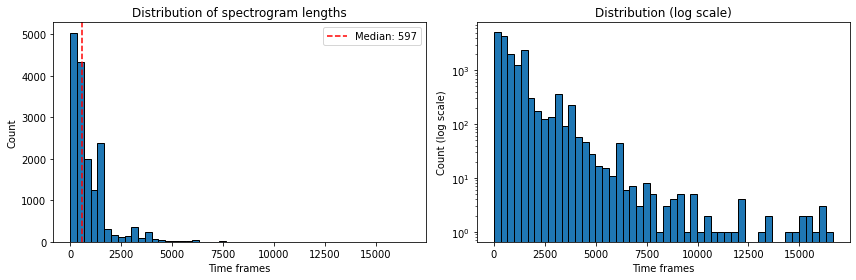


Total samples: 16738


In [7]:
#6 - Analyze time dimension distribution
import numpy as np
import matplotlib.pyplot as plt

# Extract time dimensions
time_dims = data['spectrogram'].apply(lambda x: len(x[0]))

print("Time dimension statistics:")
print(f"  Min: {time_dims.min()}")
print(f"  Max: {time_dims.max()}")
print(f"  Mean: {time_dims.mean():.1f}")
print(f"  Median: {time_dims.median():.1f}")
print(f"  Std: {time_dims.std():.1f}")

# Percentiles to guide truncation/padding decision
percentiles = [25, 50, 75, 90, 95, 99]
print("\nPercentiles:")
for p in percentiles:
    print(f"  {p}th: {np.percentile(time_dims, p):.0f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(time_dims, bins=50, edgecolor='black')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of spectrogram lengths')
axes[0].axvline(time_dims.median(), color='r', linestyle='--', label=f'Median: {time_dims.median():.0f}')
axes[0].legend()

# Log scale for better visualization of spread
axes[1].hist(time_dims, bins=50, edgecolor='black', log=True)
axes[1].set_xlabel('Time frames')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution (log scale)')

plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150)
plt.show()

print(f"\nTotal samples: {len(time_dims)}")

In [8]:
#7 - Investigate short recordings and length vs label relationship
import numpy as np

# Add time dimension to dataframe for analysis
data['time_frames'] = data['spectrogram'].apply(lambda x: len(x[0]))

# Check very short recordings
short_threshold = 100
short_recordings = data[data['time_frames'] < short_threshold]
print(f"Recordings with < {short_threshold} frames: {len(short_recordings)}")
print(f"Their task distribution:\n{short_recordings['task_name'].value_counts()}")
print(f"Their PD label distribution:\n{short_recordings['parkinsons_label'].value_counts()}")

# Check if length correlates with PD status (potential bias)
print("\n--- Time frames by PD status ---")
for label in [0, 1]:
    subset = data[data['parkinsons_label'] == label]['time_frames']
    print(f"PD={label}: mean={subset.mean():.1f}, median={subset.median():.1f}, n={len(subset)}")

# Check task distribution overall
print("\n--- Task distribution ---")
print(data['task_name'].value_counts())

# Check task distribution by PD status
print("\n--- Tasks by PD status ---")
print(pd.crosstab(data['task_name'], data['parkinsons_label']))

Recordings with < 100 frames: 184
Their task distribution:
task_name
Respiration-and-cough-Breath-2               20
Respiration-and-cough-Cough-2                20
Respiration-and-cough-FiveBreaths-3          20
Respiration-and-cough-FiveBreaths-4          20
Respiration-and-cough-ThreeQuickBreaths-2    19
Free-speech-2                                12
Free-speech-3                                 8
Story-recall                                  8
Cape-V-sentences-2                            6
Cinderella-Story                              6
Free-speech-1                                 5
Cape-V-sentences-3                            4
Respiration-and-cough-Cough-1                 3
Cape-V-sentences-4                            3
Diadochokinesis-KA                            3
Diadochokinesis-TA                            3
Rainbow-Passage                               3
Loudness                                      2
Respiration-and-cough-Breath-1                2
Cape-V-sentences-6 

Short recordings (<100 frames): Mostly respiration/breath tasks, these are intentionally short (breaths, coughs). Not data quality issues, just naturally short tasks.
Length by PD status: Slight difference (PD=1 has mean 1062 vs PD=0 has 904), but medians are similar (607 vs 592). Not a major concern for bias.

Critical finding, Task imbalance by PD status:

Some tasks have almost NO PD patients: Cape-V-sentences (218 vs 1), Caterpillar-Passage (218 vs 1), Free-Speech (167 vs 0)
Some tasks have MORE PD than non-PD: Cinderella-Story (66 vs 85), Word-color-Stroop (67 vs 84)
Balanced tasks: Diadochokinesis-*, Rainbow-Passage, Prolonged-vowel, etc. (~395 vs ~86)


This is important: If we train on all tasks together, the model might learn task-specific patterns rather than PD-specific voice biomarkers. The imbalanced task distribution could confound results.

In [9]:
#8 - All tasks (>=100 frames) + preprocess + participant split

import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TARGET_SEQ_LEN = 1024

print("CELL #8C: All tasks, recordings >=100 frames")

# use all available tasks
all_tasks = sorted(data['task_name'].dropna().unique())

# filter data
data_exp = data[
    (data['task_name'].isin(all_tasks)) &
    (data['time_frames'] >= 100)
].copy()

# cohort summary
print("\nCohort summary")
print("Samples:", len(data_exp))
print("PD samples:", int(data_exp['parkinsons_label'].sum()))
print("Non-PD samples:", int((data_exp['parkinsons_label'] == 0).sum()))
print("PD ratio:", f"{data_exp['parkinsons_label'].mean():.2%}")

print("\nParticipants")
print("Total:", data_exp['participant_id'].nunique())
print("PD:", data_exp.loc[data_exp['parkinsons_label']==1, 'participant_id'].nunique())
print("Non-PD:", data_exp.loc[data_exp['parkinsons_label']==0, 'participant_id'].nunique())

print("\nTop tasks by sample count")
print(data_exp['task_name'].value_counts().head(15))

# preprocess spectrograms
def process_spectrogram_raw(spec_raw, target_len=1024):
    spec = np.stack(spec_raw).astype(np.float32)
    _, time_len = spec.shape

    if time_len < target_len:
        spec = np.pad(spec, ((0, 0), (0, target_len - time_len)), mode='reflect')
    elif time_len > target_len:
        start = (time_len - target_len) // 2
        spec = spec[:, start:start + target_len]

    return spec

X_list = []
for _, row in tqdm(data_exp.iterrows(), total=len(data_exp), desc="Processing"):
    X_list.append(process_spectrogram_raw(row['spectrogram'], TARGET_SEQ_LEN))

X_raw = np.stack(X_list)
y_raw = data_exp['parkinsons_label'].values.astype(int)
participants_raw = data_exp['participant_id'].values

print("\nProcessed data")
print("X_raw:", X_raw.shape)
print("y_raw:", y_raw.shape)
print("Value range:", f"[{X_raw.min():.2f}, {X_raw.max():.2f}]")

# participant-level split
unique_parts = np.unique(participants_raw)
part_labels = np.array([y_raw[participants_raw == p][0] for p in unique_parts])

train_parts, test_parts = train_test_split(
    unique_parts,
    test_size=0.2,
    stratify=part_labels,
    random_state=RANDOM_STATE
)

train_mask = np.isin(participants_raw, train_parts)
test_mask = np.isin(participants_raw, test_parts)

X_train = X_raw[train_mask]
y_train = y_raw[train_mask]
parts_train = participants_raw[train_mask]

X_test = X_raw[test_mask]
y_test = y_raw[test_mask]
parts_test = participants_raw[test_mask]

print("\nSplit summary")
print("Train:", len(X_train), "samples from", len(train_parts), "participants | PD%:", f"{y_train.mean():.1%}")
print("Test:", len(X_test), "samples from", len(test_parts), "participants | PD%:", f"{y_test.mean():.1%}")

assert len(set(train_parts) & set(test_parts)) == 0
print("No participant overlap")

CELL #8C: All tasks, recordings >=100 frames

Cohort summary
Samples: 16554
PD samples: 3126
Non-PD samples: 13428
PD ratio: 18.88%

Participants
Total: 442
PD: 61
Non-PD: 381

Top tasks by sample count
task_name
Glides-Low-to-High                     482
Prolonged-vowel                        482
Maximum-phonation-time-1               481
Glides-High-to-Low                     481
Diadochokinesis-Pataka                 481
Diadochokinesis-buttercup              481
Diadochokinesis-PA                     480
Maximum-phonation-time-3               480
Maximum-phonation-time-2               480
Loudness                               479
Diadochokinesis-TA                     478
Rainbow-Passage                        478
Diadochokinesis-KA                     478
Respiration-and-cough-FiveBreaths-2    478
Respiration-and-cough-FiveBreaths-1    478
Name: count, dtype: int64


Processing: 100%|██████████| 16554/16554 [00:12<00:00, 1303.26it/s]



Processed data
X_raw: (16554, 201, 1024)
y_raw: (16554,)
Value range: [-100.00, 46.02]

Split summary
Train: 13230 samples from 353 participants | PD%: 19.6%
Test: 3324 samples from 89 participants | PD%: 16.2%
No participant overlap


In [10]:
# Check task count before and after >=100 frame filter
import numpy as np

# data should be the merged dataframe from Cell #4 (all 16,738 recordings)
print(f"Total unique tasks (before filter): {data['task_name'].nunique()}")
print(f"Total recordings (before filter): {len(data)}")

# compute time frames per recording
lengths = data['spectrogram'].apply(lambda x: np.stack(x).shape[1])
data_filtered = data[lengths >= 100]

print(f"\nTotal unique tasks (after >=100 filter): {data_filtered['task_name'].nunique()}")
print(f"Total recordings (after filter): {len(data_filtered)}")

# show which tasks were removed
tasks_before = set(data['task_name'].unique())
tasks_after = set(data_filtered['task_name'].unique())
removed = tasks_before - tasks_after

if removed:
    print(f"\nTasks fully removed by filter: {removed}")
else:
    print("\nNo tasks fully removed by filter")

Total unique tasks (before filter): 49
Total recordings (before filter): 16738

Total unique tasks (after >=100 filter): 49
Total recordings (after filter): 16554

No tasks fully removed by filter


In [11]:
data

,participant_id,session_id,task_name,spectrogram,parkinsons_label,time_frames
0,004d42e9,07031CC3,Animal-fluency,"[[3.2496545, 0.8633412, 0.29140452, -15.261607...",0,3002
1,004d42e9,07031CC3,Cinderella-Story,"[[25.801548, 24.044765, 21.460907, 19.336544, ...",0,12225
2,004d42e9,07031CC3,Diadochokinesis-KA,"[[6.3775296, -1.740032, 0.43280378, -1.7143023...",0,214
3,004d42e9,07031CC3,Diadochokinesis-PA,"[[-1.0060488, 6.1646547, -4.6716743, 4.032196,...",0,197
4,004d42e9,07031CC3,Diadochokinesis-Pataka,"[[10.043777, 8.007287, -10.674883, -1.3969623,...",0,434
...,...,...,...,...,...,...
16733,ff75b163,6A3E7090,Respiration-and-cough-FiveBreaths-3,"[[-35.432247, -14.959985, -30.736385, -30.3179...",0,1272
16734,ff75b163,6A3E7090,Respiration-and-cough-FiveBreaths-4,"[[-35.260933, -14.318013, -24.72065, -36.13139...",0,1195
16735,ff75b163,6A3E7090,Respiration-and-cough-ThreeQuickBreaths-1,"[[-35.71225, -15.318985, -27.307709, -31.39137...",0,704
16736,ff75b163,6A3E7090,Respiration-and-cough-ThreeQuickBreaths-2,"[[-35.452, -15.193077, -28.137764, -35.03787, ...",0,770


In [12]:
# sanity check after 8C (all tasks, >=100 frames)

print("Sanity check: C_all_tasks_ge100")

print("\nShapes")
print("X_raw:", X_raw.shape)
print("y_raw:", y_raw.shape)
print("participants_raw:", participants_raw.shape)

print("\nLabels (recording-level)")
print(pd.Series(y_raw).value_counts().sort_index())

print("\nParticipants (participant-level)")
parts_df = pd.DataFrame({"participant_id": participants_raw, "parkinsons_label": y_raw}).drop_duplicates()
print(parts_df["parkinsons_label"].value_counts().sort_index())
print("Total participants:", parts_df["participant_id"].nunique())

print("\nTrain/Test leakage check")
print("Train participants:", len(np.unique(parts_train)))
print("Test participants:", len(np.unique(parts_test)))
print("Overlap:", len(set(np.unique(parts_train)) & set(np.unique(parts_test))))

print("\nTrain/Test label balance (recording-level)")
print("Train PD%:", f"{y_train.mean():.2%}", "| n=", len(y_train))
print("Test  PD%:", f"{y_test.mean():.2%}", "| n=", len(y_test))

print("\nTrain/Test label balance (participant-level)")
train_parts_df = pd.DataFrame({"participant_id": parts_train, "parkinsons_label": y_train}).drop_duplicates()
test_parts_df = pd.DataFrame({"participant_id": parts_test, "parkinsons_label": y_test}).drop_duplicates()
print("Train participants PD%:", f"{train_parts_df['parkinsons_label'].mean():.2%}",
      "| PD:", int(train_parts_df['parkinsons_label'].sum()), "| Total:", len(train_parts_df))
print("Test participants PD%:", f"{test_parts_df['parkinsons_label'].mean():.2%}",
      "| PD:", int(test_parts_df['parkinsons_label'].sum()), "| Total:", len(test_parts_df))


Sanity check: C_all_tasks_ge100

Shapes
X_raw: (16554, 201, 1024)
y_raw: (16554,)
participants_raw: (16554,)

Labels (recording-level)
0    13428
1     3126
Name: count, dtype: int64

Participants (participant-level)
parkinsons_label
0    381
1     61
Name: count, dtype: int64
Total participants: 442

Train/Test leakage check
Train participants: 353
Test participants: 89
Overlap: 0

Train/Test label balance (recording-level)
Train PD%: 19.56% | n= 13230
Test  PD%: 16.19% | n= 3324

Train/Test label balance (participant-level)
Train participants PD%: 13.88% | PD: 49 | Total: 353
Test participants PD%: 13.48% | PD: 12 | Total: 89


In [13]:
# 9: Precompute AST-sized spectrograms once for CV (all tasks, >=100 frames)

from scipy.ndimage import zoom
import numpy as np
from tqdm import tqdm

TARGET_MEL = 128
TARGET_TIME = 1024

def resize_for_ast(spec):
    mel_ratio = TARGET_MEL / spec.shape[0]
    time_ratio = TARGET_TIME / spec.shape[1]
    return zoom(spec, (mel_ratio, time_ratio), order=1).astype(np.float32)

print("Precomputing AST-sized spectrograms...")

X_ast = []
for x in tqdm(X_raw, desc="Resizing"):
    X_ast.append(resize_for_ast(x))

X_ast = np.stack(X_ast)

print("X_ast shape:", X_ast.shape)

# global index mapping (used in CV)
participants_ast = participants_raw.copy()
labels_ast = y_raw.copy()

print("Done.")


Precomputing AST-sized spectrograms...


Resizing: 100%|██████████| 16554/16554 [00:36<00:00, 450.99it/s]


X_ast shape: (16554, 128, 1024)
Done.


In [15]:
# 10: 5-fold participant-level CV on precomputed AST inputs
# expects: X_ast (N,128,1024), labels_ast (N,), participants_ast (N,)

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import ASTModel
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from tqdm import tqdm
import numpy as np
import copy
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class ASTClassifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, freeze_base=False):
        super().__init__()
        if not pretrained:
            raise ValueError("Use pretrained=True")
        self.ast = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
        hidden = self.ast.config.hidden_size

        if freeze_base:
            for p in self.ast.parameters():
                p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)  # (B,128,1024) -> (B,1024,128)
        out = self.ast(input_values=x)
        return self.classifier(out.pooler_output)

class ASTDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, pids, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.pids = np.array(pids)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()

        if self.augment:
            if np.random.rand() < 0.5:
                t = np.random.randint(50, 150)
                t0 = np.random.randint(0, max(1, x.shape[1] - t))
                x[:, t0:t0+t] = 0
            if np.random.rand() < 0.5:
                f = np.random.randint(10, 30)
                f0 = np.random.randint(0, max(1, x.shape[0] - f))
                x[f0:f0+f, :] = 0

        return {"inputs": x, "labels": self.y[idx], "participant": self.pids[idx]}

class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

def participant_metrics(probs, labs, pids):
    probs = np.asarray(probs)
    labs = np.asarray(labs).astype(int)
    pids = np.asarray(pids)

    uniq = np.unique(pids)
    part_probs, part_labs = [], []
    for pid in uniq:
        m = (pids == pid)
        part_probs.append(probs[m].mean())
        part_labs.append(labs[m][0])

    part_probs = np.array(part_probs)
    part_labs = np.array(part_labs).astype(int)

    if len(np.unique(part_labs)) > 1:
        auc = roc_auc_score(part_labs, part_probs)
        fpr, tpr, thr = roc_curve(part_labs, part_probs)
        opt_idx = np.argmax(tpr - fpr)
        opt_thr = float(thr[opt_idx])
    else:
        auc = 0.5
        opt_thr = 0.5

    preds_opt = (part_probs >= opt_thr).astype(int)

    f1_opt = f1_score(part_labs, preds_opt, zero_division=0)
    rec_opt = recall_score(part_labs, preds_opt, zero_division=0)
    prec_opt = precision_score(part_labs, preds_opt, zero_division=0)

    return auc, f1_opt, rec_opt, prec_opt, opt_thr, uniq, part_probs, part_labs

unique_parts = np.unique(participants_ast)
part_labels = np.array([labels_ast[participants_ast == p][0] for p in unique_parts]).astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

max_epochs = 20
patience = 5

fold_rows = []
all_oof_probs = np.zeros(len(unique_parts), dtype=np.float32)

start = time.time()

fold_bar = tqdm(list(skf.split(unique_parts, part_labels)), desc="Folds", total=5)
for fold, (tr_idx, va_idx) in enumerate(fold_bar, start=1):

    tr_parts = unique_parts[tr_idx]
    va_parts = unique_parts[va_idx]

    tr_mask = np.isin(participants_ast, tr_parts)
    va_mask = np.isin(participants_ast, va_parts)

    X_tr = X_ast[tr_mask]
    y_tr = labels_ast[tr_mask].astype(int)
    p_tr = participants_ast[tr_mask]

    X_va = X_ast[va_mask]
    y_va = labels_ast[va_mask].astype(int)
    p_va = participants_ast[va_mask]

    mean, std = X_tr.mean(), X_tr.std()
    X_tr = (X_tr - mean) / (std + 1e-8)
    X_va = (X_va - mean) / (std + 1e-8)

    ds_tr = ASTDataset(X_tr, y_tr, p_tr, augment=True)
    ds_va = ASTDataset(X_va, y_va, p_va, augment=False)

    neg = int((y_tr == 0).sum())
    pos = int((y_tr == 1).sum())
    w0 = 1.0
    w1 = neg / max(1, pos)

    class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)

    sample_weights = np.where(y_tr == 1, w1, w0).astype(np.float64)
    sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    dl_tr = torch.utils.data.DataLoader(ds_tr, batch_size=8, sampler=sampler, num_workers=0, pin_memory=True)
    dl_va = torch.utils.data.DataLoader(ds_va, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

    model = ASTClassifier(num_classes=2, pretrained=True, freeze_base=False).to(device)

    optimizer = torch.optim.AdamW(
        [
            {"params": model.ast.parameters(), "lr": 5e-6, "weight_decay": 0.01},
            {"params": model.classifier.parameters(), "lr": 5e-4, "weight_decay": 0.01},
        ],
        betas=(0.9, 0.999),
    )

    criterion = FocalLoss(class_weights, gamma=2.0)

    best_state = None
    best_score = -1e9
    wait = 0

    epoch_bar = tqdm(range(1, max_epochs + 1), desc=f"Fold {fold} epochs", leave=False)
    for epoch in epoch_bar:
        model.train()
        for b in dl_tr:
            optimizer.zero_grad()
            out = model(b["inputs"].to(device))
            loss = criterion(out, b["labels"].to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        probs, labs, pids = [], [], []
        with torch.no_grad():
            for b in dl_va:
                o = model(b["inputs"].to(device))
                probs.extend(torch.softmax(o, 1)[:, 1].cpu().numpy())
                labs.extend(b["labels"].cpu().numpy())
                pids.extend(b["participant"])

        auc, f1opt, rec, prec, thr, _, _, _ = participant_metrics(probs, labs, pids)
        score = 0.4 * auc + 0.6 * f1opt

        epoch_bar.set_postfix(auc=f"{auc:.3f}", f1opt=f"{f1opt:.3f}", thr=f"{thr:.3f}", wait=wait)

        if score > best_score + 1e-6:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)

    model.eval()
    probs, labs, pids = [], [], []
    with torch.no_grad():
        for b in dl_va:
            o = model(b["inputs"].to(device))
            probs.extend(torch.softmax(o, 1)[:, 1].cpu().numpy())
            labs.extend(b["labels"].cpu().numpy())
            pids.extend(b["participant"])

    auc, f1opt, rec, prec, thr, uniq_va, part_probs, part_labs = participant_metrics(probs, labs, pids)

    for i, pid in enumerate(uniq_va):
        idx = np.where(unique_parts == pid)[0][0]
        all_oof_probs[idx] = part_probs[i]

    fold_rows.append((auc, f1opt, rec, prec, thr))

    fold_bar.set_postfix(
        fold=fold,
        auc=f"{auc:.3f}",
        f1opt=f"{f1opt:.3f}",
        rec=f"{rec:.3f}",
        prec=f"{prec:.3f}",
        thr=f"{thr:.3f}",
    )

    del model, optimizer, ds_tr, ds_va, dl_tr, dl_va
    torch.cuda.empty_cache()

elapsed = (time.time() - start) / 60.0

aucs = np.array([r[0] for r in fold_rows])
f1s  = np.array([r[1] for r in fold_rows])
recs = np.array([r[2] for r in fold_rows])
precs= np.array([r[3] for r in fold_rows])
thrs = np.array([r[4] for r in fold_rows])

print("\nPer-fold metrics: AUC, F1_opt, Recall, Precision, Threshold")
for i, r in enumerate(fold_rows, start=1):
    print(f"Fold {i}: {r[0]:.4f}  {r[1]:.4f}  {r[2]:.4f}  {r[3]:.4f}  {r[4]:.3f}")

print("\nCV summary (mean ± std)")
print("AUC:      ", f"{aucs.mean():.4f}", "±", f"{aucs.std():.4f}")
print("F1_opt:   ", f"{f1s.mean():.4f}",  "±", f"{f1s.std():.4f}")
print("Recall:   ", f"{recs.mean():.4f}", "±", f"{recs.std():.4f}")
print("Precision:", f"{precs.mean():.4f}","±", f"{precs.std():.4f}")
print("Thr:      ", f"{thrs.mean():.3f}",  "±", f"{thrs.std():.3f}")
print("Total time (min):", f"{elapsed:.1f}")

oof_auc = roc_auc_score(part_labels, all_oof_probs)
print("OOF AUC:", f"{oof_auc:.4f}")


Device: cuda


Folds: 100%|██████████| 5/5 [15:41:20<00:00, 11296.02s/it, auc=0.965, f1opt=0.750, fold=5, prec=0.600, rec=1.000, thr=0.653]  


Per-fold metrics: AUC, F1_opt, Recall, Precision, Threshold
Fold 1: 0.9470  0.7742  1.0000  0.6316  0.343
Fold 2: 0.9524  0.7742  0.9231  0.6667  0.397
Fold 3: 0.9243  0.7273  1.0000  0.5714  0.440
Fold 4: 0.7873  0.5455  0.7500  0.4286  0.708
Fold 5: 0.9649  0.7500  1.0000  0.6000  0.653

CV summary (mean ± std)
AUC:       0.9152 ± 0.0653
F1_opt:    0.7142 ± 0.0862
Recall:    0.9346 ± 0.0970
Precision: 0.5796 ± 0.0819
Thr:       0.508 ± 0.145
Total time (min): 941.3
OOF AUC: 0.8680


In [1]:
# CI calculation (ddof=1) - PD All Tasks
from scipy import stats
import numpy as np

aucs = [0.9470, 0.9524, 0.9243, 0.7873, 0.9649]
f1s = [0.7742, 0.7742, 0.7273, 0.5455, 0.7500]
recalls = [1.000, 0.9231, 1.000, 0.750, 1.000]
precs = [0.6316, 0.6667, 0.5714, 0.4286, 0.600]

n = 5
t_crit = stats.t.ppf(0.975, df=n - 1)

print("PD All Tasks — Per-fold summary (ddof=1)")
for name, arr in [("AUC", aucs), ("F1", f1s), ("Recall", recalls), ("Precision", precs)]:
    m = np.mean(arr)
    sd = np.std(arr, ddof=1)
    se = sd / np.sqrt(n)
    ci_lo = m - t_crit * se
    ci_hi = m + t_crit * se
    print(f"  {name}: {m:.4f} +/- {sd:.4f} [{ci_lo:.4f}, {ci_hi:.4f}]")

PD All Tasks — Per-fold summary (ddof=1)
  AUC: 0.9152 +/- 0.0730 [0.8246, 1.0058]
  F1: 0.7142 +/- 0.0963 [0.5946, 0.8338]
  Recall: 0.9346 +/- 0.1084 [0.8000, 1.0693]
  Precision: 0.5797 +/- 0.0916 [0.4659, 0.6934]


# We conducted ablation C by selecting all tasks with more than 100 frames and training 5 fold. The results were strong, indicating that AST performs better even in the presence of a high class imbalance in the PD category.